In [1]:
PATH_BioData = "../../../DATASETS/BioData_backup_alex/"

PATH_MBLs = PATH_BioData + "max_mbl_per_category.csv"
PATH_SEQ = PATH_BioData + "accessions_sequence_organisms.csv"
PATH_labels = "../../../DATASETS/raw_data/uniprot_ids_labeled.csv"

In [2]:
import pandas as pd

In [3]:
# Load datasets
df_mbls = pd.read_csv(PATH_MBLs)
df_seq = pd.read_csv(PATH_SEQ)
df_labels = pd.read_csv(PATH_labels)

df_seq["seq_length"] = df_seq["sequence"].apply(len)

In [4]:
# Display columns of each dataset
print("Columns in max_mbl_per_category.csv:")
print(df_mbls.columns)
print(f"Length: {len(df_mbls)}")

print("\nColumns in accessions_sequence_organisms.csv:")
print(df_seq.columns)
print(f"Length: {len(df_seq)}")

print("\nColumns in uniprot_ids_labeled.csv:")
print(df_labels.columns)
print(f"Length: {len(df_labels)}")

Columns in max_mbl_per_category.csv:
Index(['accession_code', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl'], dtype='object')
Length: 1270

Columns in accessions_sequence_organisms.csv:
Index(['accession_id', 'sequence', 'organism', 'organelle', 'taxonomy_id',
       'seq_length'],
      dtype='object')
Length: 1416

Columns in uniprot_ids_labeled.csv:
Index(['uniprot_id', 'class'], dtype='object')
Length: 1433


In [5]:
# Unify the dfs
# If there's no MBL in df_labels, it will be filled with -1
# If there's no sequence in df_seq, it will be removed

df = df_labels.rename(columns={"uniprot_id": "accession_code"})
df = df.merge(df_mbls, on="accession_code", how="left")
df.fillna(-1, inplace=True)  # Fill missing MBL values with -1

df_seq = df_seq.rename(columns={"accession_id": "accession_code"})
df = df.merge(df_seq, on="accession_code", how="left")
df.dropna(subset=["sequence"], inplace=True)  # Remove rows without a sequence

print("\nMerged DataFrame:")
print(f"There are {len(df)} rows and {len(df.columns)} columns.")
print(df.columns)


Merged DataFrame:
There are 1412 rows and 10 columns.
Index(['accession_code', 'class', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl',
       'sequence', 'organism', 'organelle', 'taxonomy_id', 'seq_length'],
      dtype='object')


Correlation Matrix:
               class  c_max_mbl  f_max_mbl  p_max_mbl  seq_length  organism
class       1.000000  -0.084570   0.118723  -0.095446   -0.033091  0.143670
c_max_mbl  -0.084570   1.000000   0.339836   0.421024    0.080051 -0.096600
f_max_mbl   0.118723   0.339836   1.000000   0.425829    0.095661 -0.072249
p_max_mbl  -0.095446   0.421024   0.425829   1.000000    0.061836 -0.090499
seq_length -0.033091   0.080051   0.095661   0.061836    1.000000 -0.003075
organism    0.143670  -0.096600  -0.072249  -0.090499   -0.003075  1.000000


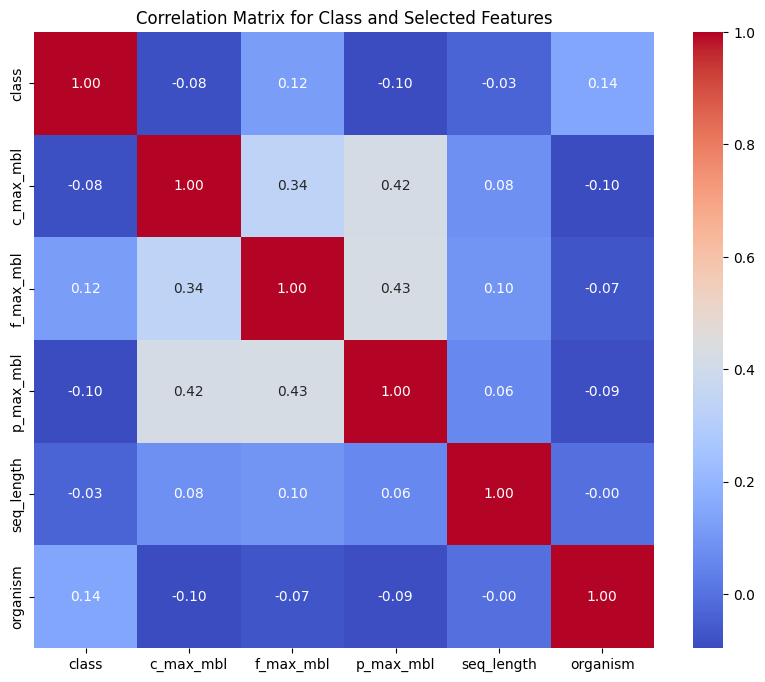

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
features = ['class', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl', 'seq_length', 'organism']

# Encode 'organism' as numerical values
df_encoded = df.copy()
df_encoded['organism'] = df_encoded['organism'].astype('category').cat.codes

# Filter the dataset to include only the relevant columns
df_corr = df_encoded[features]

# Compute the correlation matrix
correlation_matrix = df_corr.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Class and Selected Features")
plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df["organism"] = df["organism"].str.replace(r"\s*\(.*?\)", "", regex=True)

# Group by organism and count the number of proteins
organism_counts = df.groupby("organism").size().reset_index(name="protein_count")

# Filter organisms with at least 6 rows
organisms_at_least_6 = organism_counts[organism_counts["protein_count"] >= 6]

# Group organisms with 1 to 5 samples
organisms_1_to_5 = organism_counts[(organism_counts["protein_count"] >= 1) & (organism_counts["protein_count"] <= 5)]

# Add class counts (True/False) for organisms with at least 6 rows
class_counts = (
    df[df["organism"].isin(organisms_at_least_6["organism"])]
    .groupby(["organism", "class"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={False: "False_count", True: "True_count"})
)

# Merge class counts with organism counts
organisms_at_least_6 = organisms_at_least_6.merge(class_counts, on="organism", how="left")

# Plot for organisms with at least 6 proteins
organisms_at_least_6 = organisms_at_least_6.sort_values(by="protein_count", ascending=False)

In [31]:
# Display results
print("Organisms with at least 10 proteins (ordered descending):")
print(organisms_at_least_6.sort_values(by="protein_count", ascending=False))

Organisms with at least 10 proteins (ordered descending):
                       organism  protein_count  False_count  True_count
7                 Homo sapiens.            657          555         102
8                 Mus musculus.            114           80          34
6             Escherichia coli.            109           75          34
11    Saccharomyces cerevisiae.            100           67          33
0         Arabidopsis thaliana.             31           21          10
10           Rattus norvegicus.             29           18          11
5      Drosophila melanogaster.             27           14          13
4             Candida albicans.             21            2          19
9   Mycobacterium tuberculosis.             16            5          11
12   Schizosaccharomyces pombe.             15           14           1
2                   Bos taurus.             14           11           3
3       Caenorhabditis elegans.              9            7           2
1     

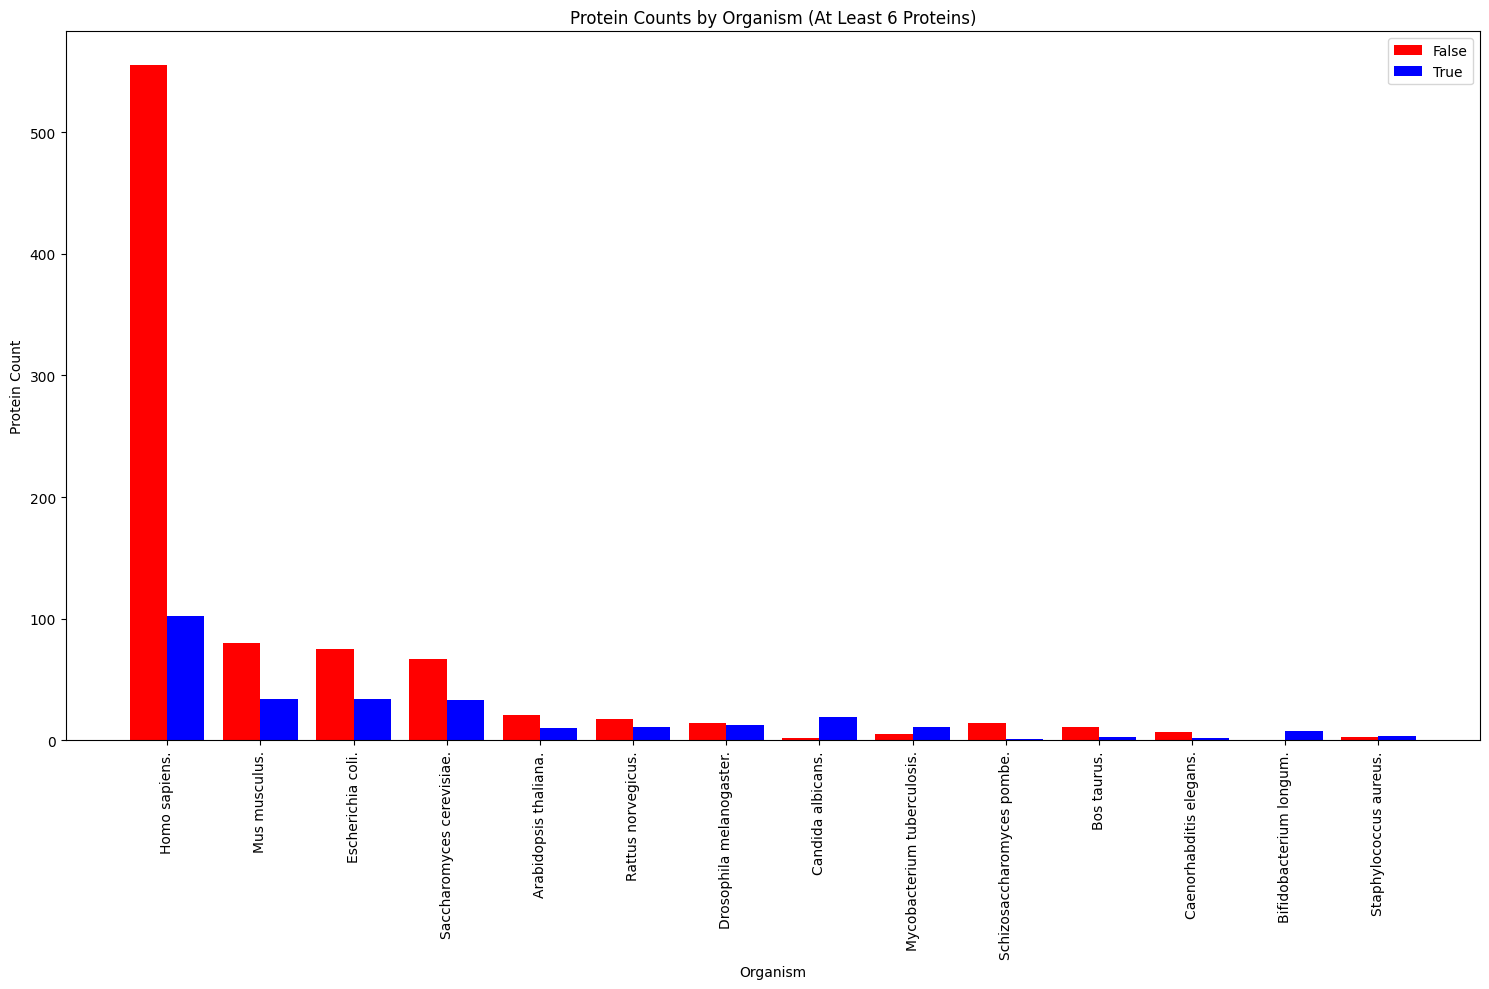

In [37]:
# Plotting
plt.figure(figsize=(15, 10))
x = np.arange(len(organisms_at_least_6))  # X-axis positions
width = 0.4  # Width of the bars

# Bars for False and True counts
plt.bar(x - width/2, organisms_at_least_6["False_count"], width, label="False", color="red")
plt.bar(x + width/2, organisms_at_least_6["True_count"], width, label="True", color="blue")

# Add labels and title
plt.xticks(x, organisms_at_least_6["organism"], rotation=90)
plt.xlabel("Organism")
plt.ylabel("Protein Count")
plt.title("Protein Counts by Organism (At Least 6 Proteins)")
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

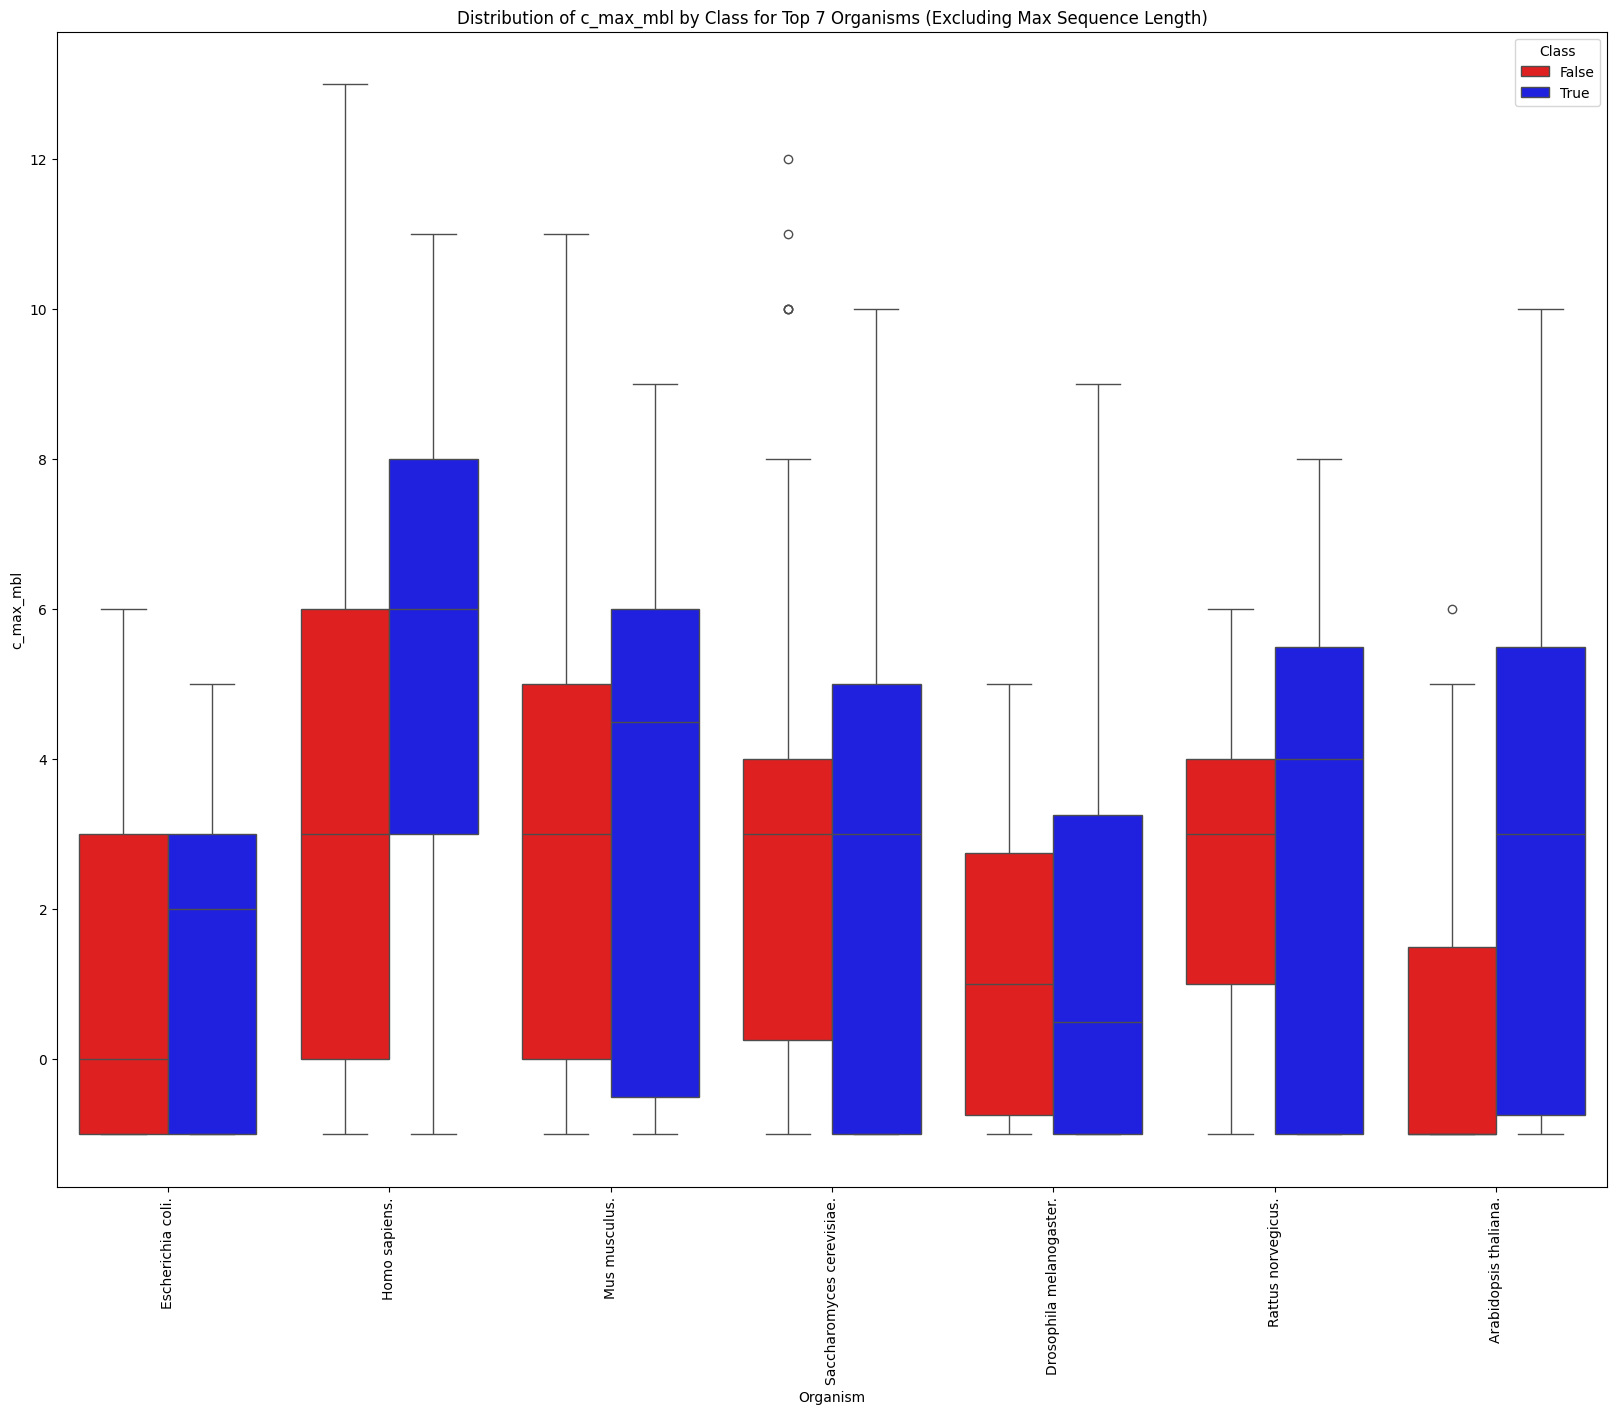

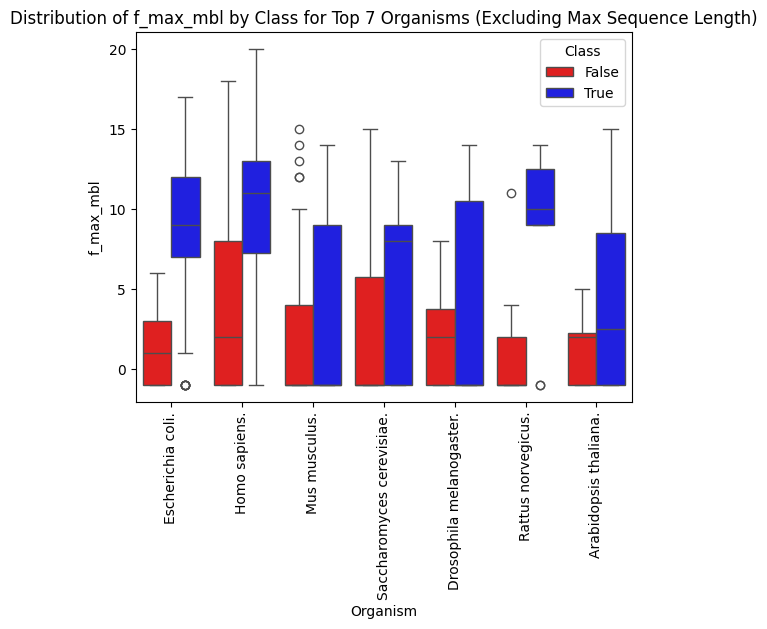

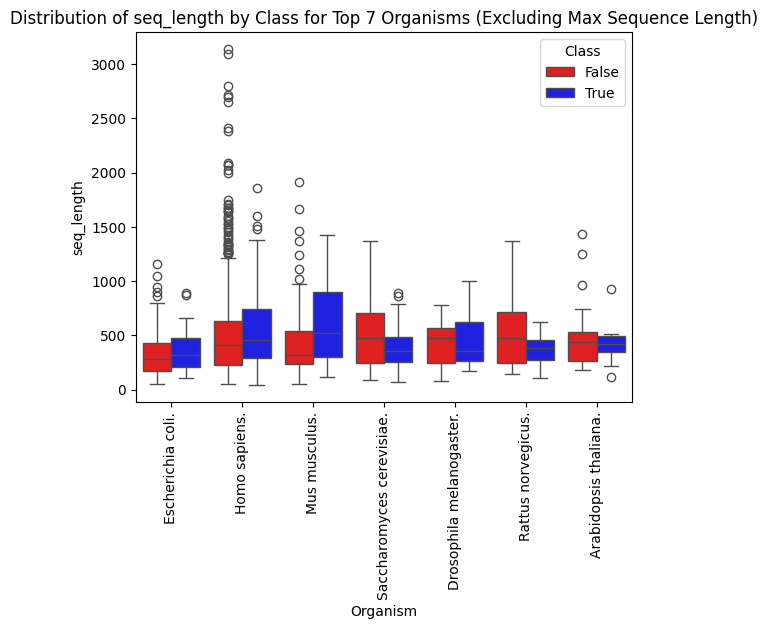

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Select the 7 biggest organisms from organisms_at_least_6
top_7_organisms = organisms_at_least_6.head(7)["organism"]

# Filter the dataset for the top 7 organisms
df_top_7 = df[df["organism"].isin(top_7_organisms)]

# Remove rows with the greatest sequence length for each organism
max_seq_indices = df_top_7.groupby("organism_cleaned")["seq_length"].idxmax()
df_top_7_filtered = df_top_7.drop(max_seq_indices)

# Create separate boxplots for each feature
features = ["c_max_mbl", "f_max_mbl", "seq_length"]

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features, 1):
    sns.boxplot(data=df_top_7_filtered, x="organism_cleaned", y=feature, hue="class", palette={False: "red", True: "blue"})
    plt.title(f"Distribution of {feature} by Class for Top 7 Organisms (Excluding Max Sequence Length)")
    plt.xlabel("Organism")
    plt.ylabel(feature)
    plt.xticks(rotation=90)
    plt.legend(title="Class")
    plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
import plotly.express as px


def _reduce_embeddings_3d(method, embeddings, n_components=3):
    """Helper function to reduce embeddings to 3D."""
    if method == "PCA":
        reducer = PCA(n_components=n_components)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == "KMeans2":
        reducer = KMeans(n_clusters=2, random_state=42)
        return reducer.fit_predict(embeddings)  # Return cluster labels for KMeans
    else:
        raise ValueError("Unsupported method. Use 'PCA', 'UMAP', or 'KMeans2'.")
    
    return reducer.fit_transform(embeddings)

def _get_colors(labels):
    """Helper function to generate colors for labels."""
    color_map = {
        False: "red",  # Assign red to Class False
        True: "blue"   # Assign blue to Class True
    }
    unique_labels = np.unique(labels)
    colors = {label: color_map.get(label, "gray") for label in unique_labels}  # Default to gray if not specified
    return colors

def _plot_3d(ax, reduced, labels, title):
    """Helper function to plot 3D scatter."""
    colors = _get_colors(labels)
    for label in np.unique(labels):
        mask = labels == label
        ax.scatter(reduced[mask, 0], reduced[mask, 1], reduced[mask, 2], 
                   label=f"Class {label}", color=colors[label], alpha=0.6)
    ax.set_title(title)
    ax.legend()

def _plot_kmeans_3d(ax, embeddings, clusters, title):
    """Helper function to plot KMeans clustering in 3D."""
    ax.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2], 
               c=clusters, cmap="coolwarm", alpha=0.6)
    ax.set_title(title)

def plots3D(method, dfs_dict, label_col="class", figsize=(15, 5), title=None):
    """
    Plot PCA, UMAP, or KMeans2 for sequence embeddings in 3D.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        dfs_dict (dict): Dictionary of DataFrames {name: DataFrame}.
        label_col (str): Column name for labels (default: "class").
        figsize (tuple): Figure size (default: (15, 5)).
        title (str): Title for the entire plot.
    """
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontsize=16)
    
    for i, (name, df) in enumerate(dfs_dict.items(), start=1):
        embeddings = np.vstack(df["embedding"].to_numpy())
        labels = df[label_col].values if label_col in df.columns else np.zeros(len(df))
        
        ax = fig.add_subplot(1, len(dfs_dict), i, projection="3d")
        
        if method == "KMeans2":
            clusters = _reduce_embeddings_3d(method, embeddings)
            _plot_kmeans_3d(ax, embeddings, clusters, f"{name} ({method})")
        else:
            reduced = _reduce_embeddings_3d(method, embeddings)
            _plot_3d(ax, reduced, labels, f"{name} ({method})")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def interactive_3Dplot(method, dfs_dict, label_col="class", id_col="code", title=None):
    """
    Create interactive 3D plots using Plotly.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        dfs_dict (dict): Dictionary of DataFrames {name: DataFrame}.
        label_col (str): Column name for labels (default: "class").
        id_col (str): Column name for unique identifiers (default: "code").
        title (str): Title for the entire plot.
    """
    for name, df in dfs_dict.items():
        embeddings = np.vstack(df["embedding"].to_numpy())
        labels = df[label_col].values if label_col in df.columns else np.zeros(len(df))
        ids = df[id_col].values if id_col in df.columns else np.arange(len(df))
        
        # Reduce embeddings to 3D
        reduced = _reduce_embeddings_3d(method, embeddings)
        
        # Create a DataFrame for Plotly
        plot_df = pd.DataFrame(reduced, columns=["x", "y", "z"])
        plot_df[label_col] = labels
        plot_df[id_col] = ids  # Add the unique identifier column
        
        # Plot with Plotly
        fig = px.scatter_3d(
            plot_df, x="x", y="y", z="z", color=label_col,
            hover_data={id_col: True, "x": False, "y": False, "z": False},  # Show id_col on hover
            title=f"{name} ({method})",
            color_discrete_map={False: "red", True: "blue"}  # Force red/blue for False/True
        )
        fig.show()

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
def load_embeddings_with_labels(embed_path, label_path, id_col="code"):
    df_embed = pd.read_csv(embed_path)
    df_labels = pd.read_csv(label_path)

    df = df_embed.merge(df_labels, how="inner", left_on=id_col, right_on="uniprot_id")

    # Fallback to catch either dim_0 or numbered columns like "0", "1", ...
    emb_cols = [col for col in df.columns if col.startswith("dim_") or col.isdigit()]
    if not emb_cols:
        raise ValueError(f"No embedding columns found in {embed_path}. Columns: {df.columns.tolist()}")

    df["embedding"] = df[emb_cols].apply(lambda row: row.values.astype(np.float32), axis=1)
    return df

In [34]:
# Paths
PATHS_EMB = {
    "ESM": "../../../DATASETS/embeddings/ESM_sequence_embeddings_with_accession.csv",
    "ProtT5": "../../../DATASETS/embeddings/ProtT5_sequence_embeddings_with_accession.csv",
    "ProstT5": "../../../DATASETS/embeddings/ProstT5_sequence_embeddings_with_accession.csv"
}

# Load all datasets
all_dfs = {name: load_embeddings_with_labels(path, PATH_labels) for name, path in PATHS_EMB.items()}

# Merge embeddings with organism information
for name, df_emb in all_dfs.items():
    # Merge df_emb with df_top_7_filtered to add organism information
    all_dfs[name] = df_emb.merge(
        df_top_7_filtered[["accession_code", "organism_cleaned"]],
        how="inner",
        left_on="uniprot_id",
        right_on="accession_code"
    )

# Create a dictionary of DataFrames for each organism
all_dfs_by_organisms = {}
for name, df_emb in all_dfs.items():
    for organism in top_7_organisms:
        filtered_df = df_emb[df_emb["organism_cleaned"] == organism]
        if organism not in all_dfs_by_organisms:
            all_dfs_by_organisms[organism] = {}
        all_dfs_by_organisms[organism][name] = filtered_df

Plotting for organism: Homo sapiens.


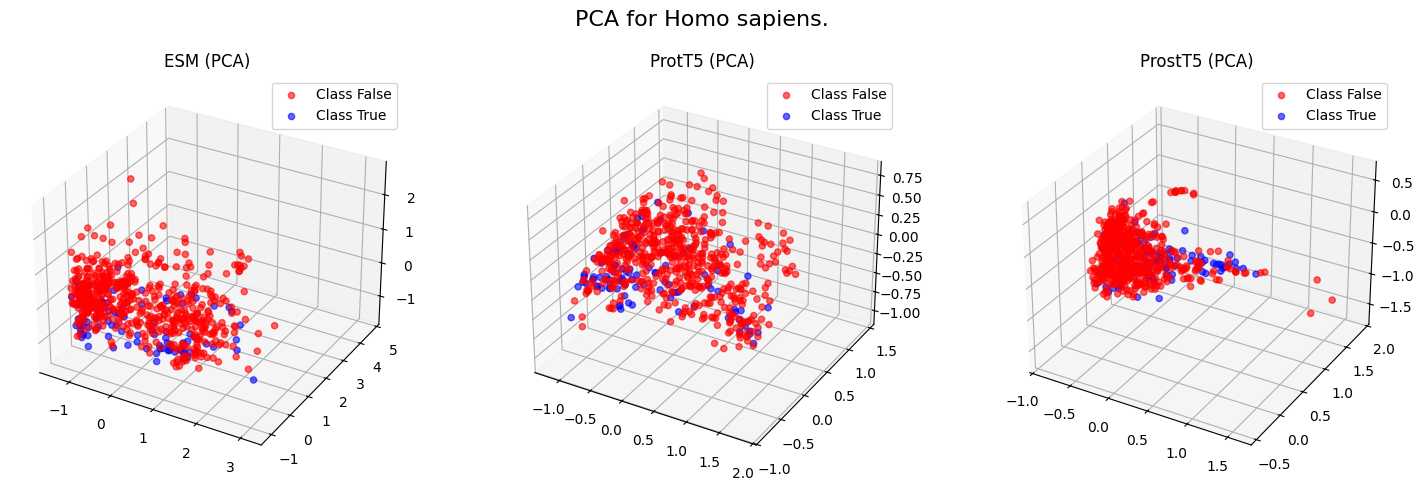

Plotting for organism: Mus musculus.


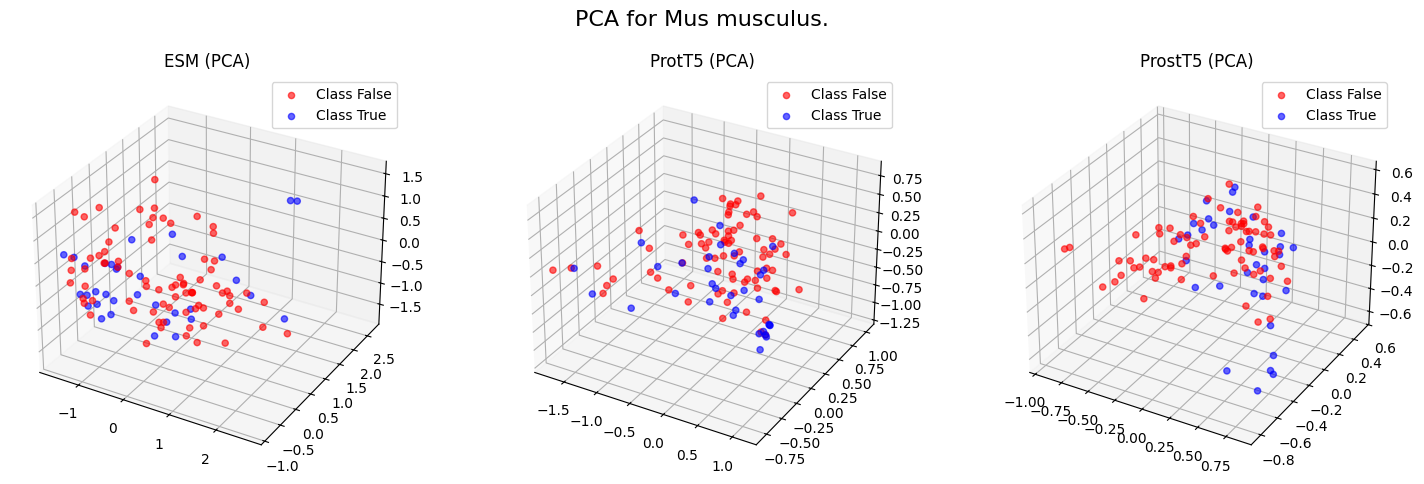

Plotting for organism: Escherichia coli.


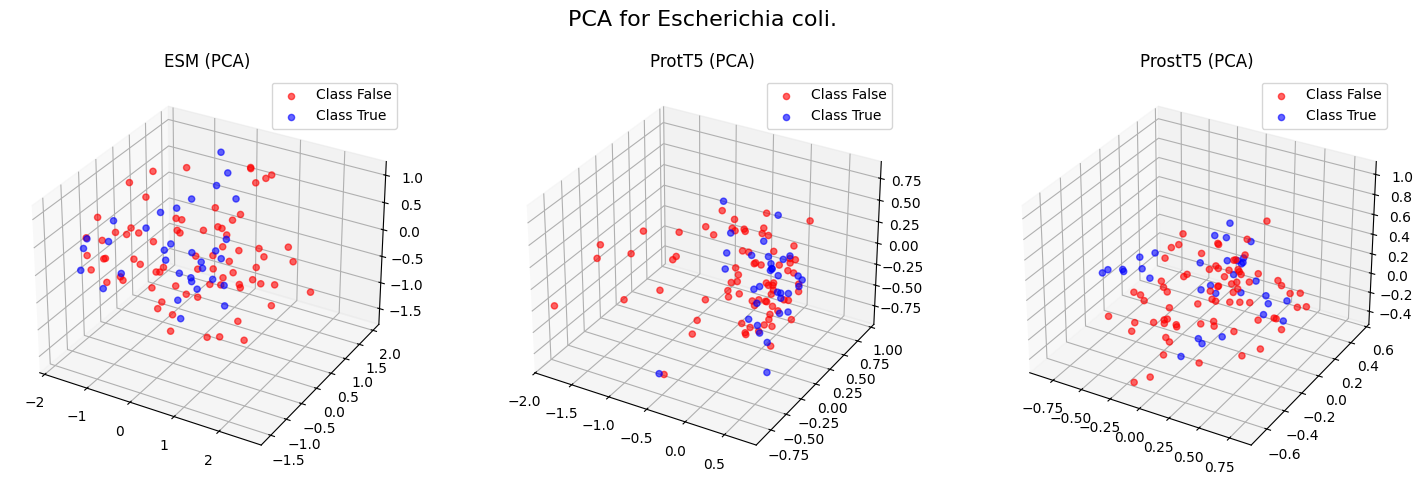

Plotting for organism: Saccharomyces cerevisiae.


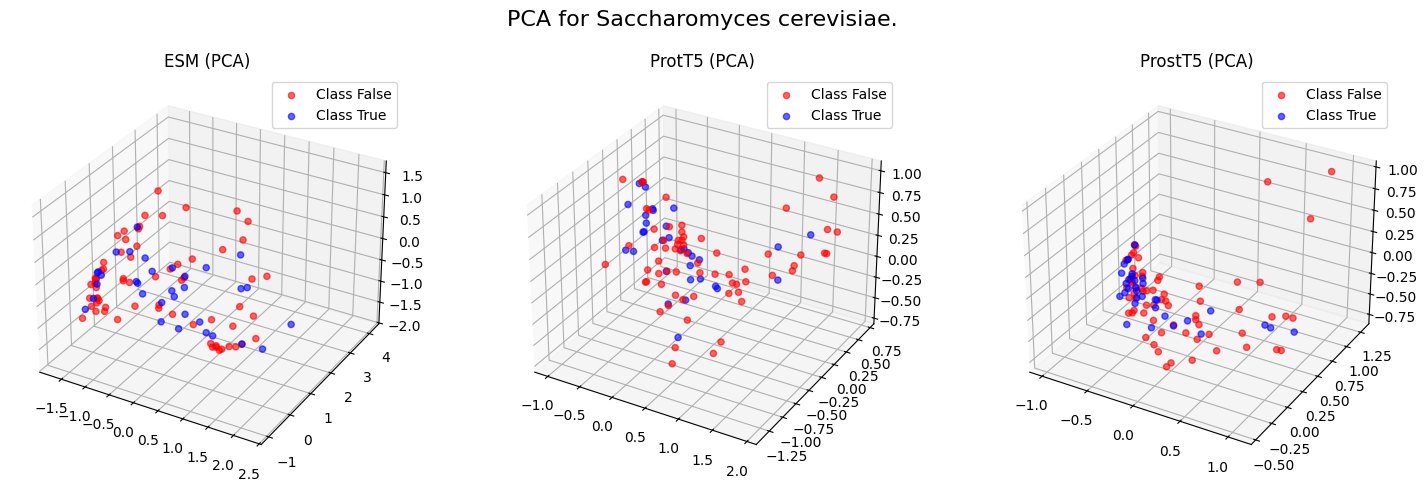

Plotting for organism: Arabidopsis thaliana.


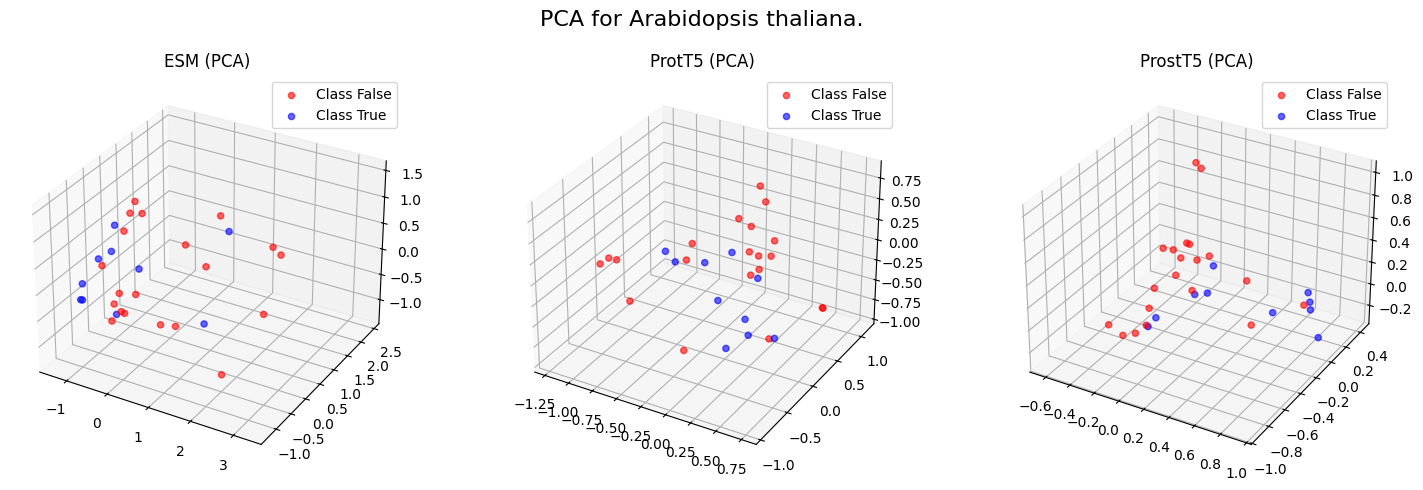

Plotting for organism: Rattus norvegicus.


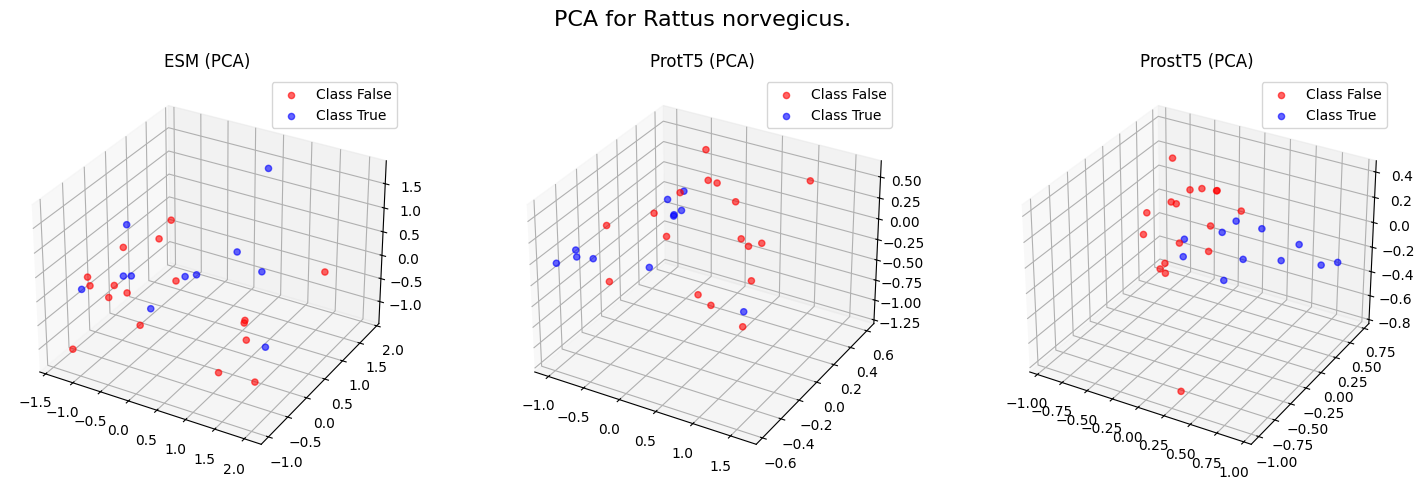

Plotting for organism: Drosophila melanogaster.


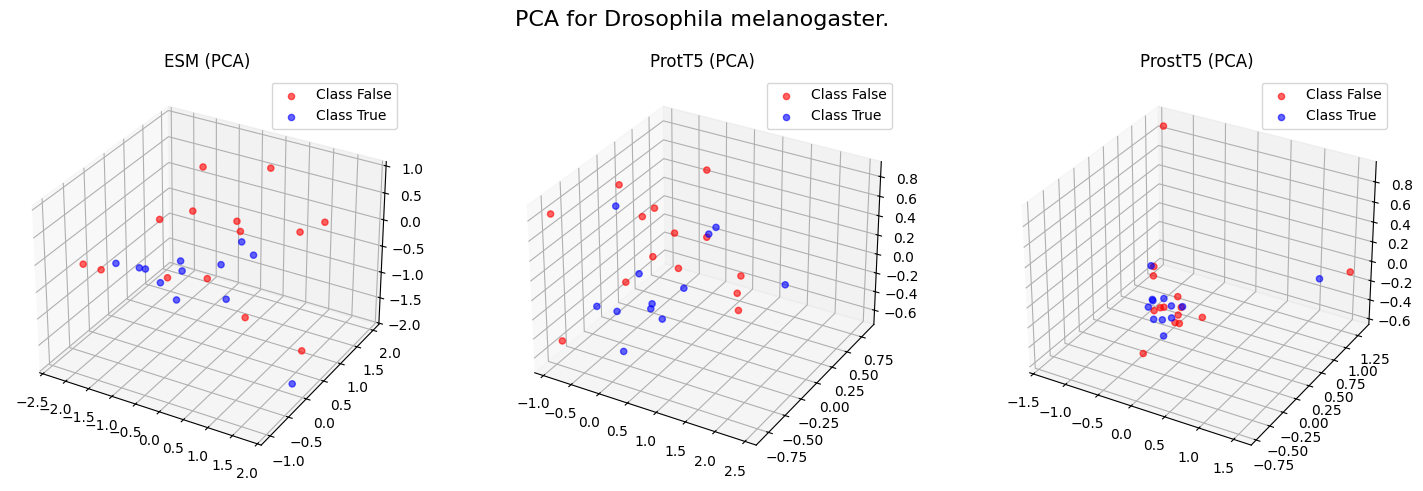

In [35]:
# Run the plots3D function for PCA for each organism
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D("PCA", dfs_dict, label_col="class", title=f"PCA for {organism}")

Plotting for organism: Homo sapiens.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/

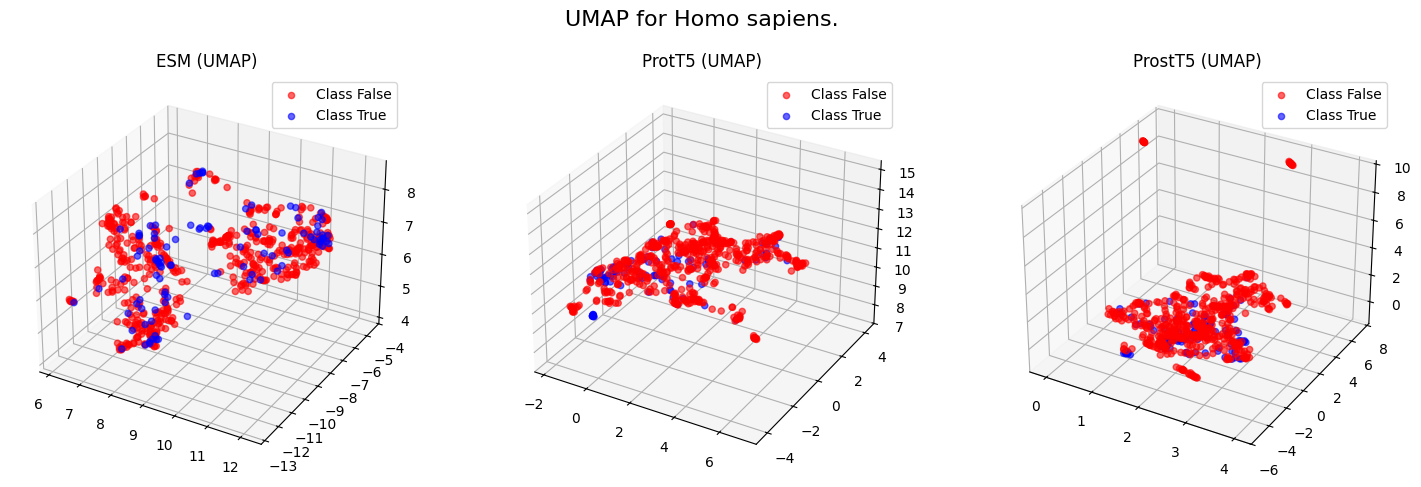

Plotting for organism: Mus musculus.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

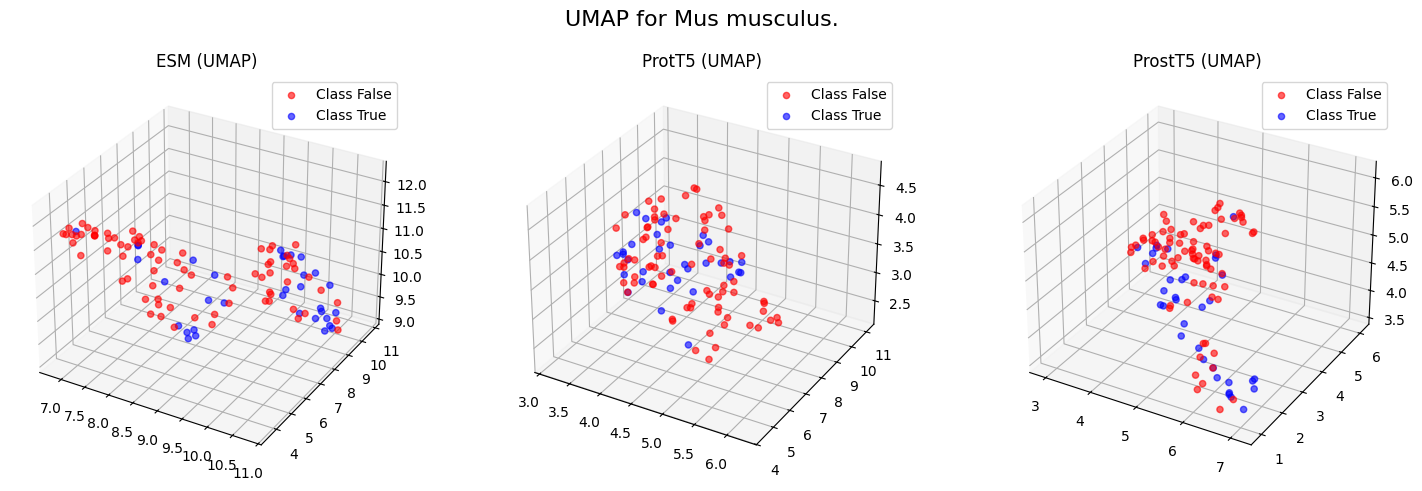

Plotting for organism: Escherichia coli.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

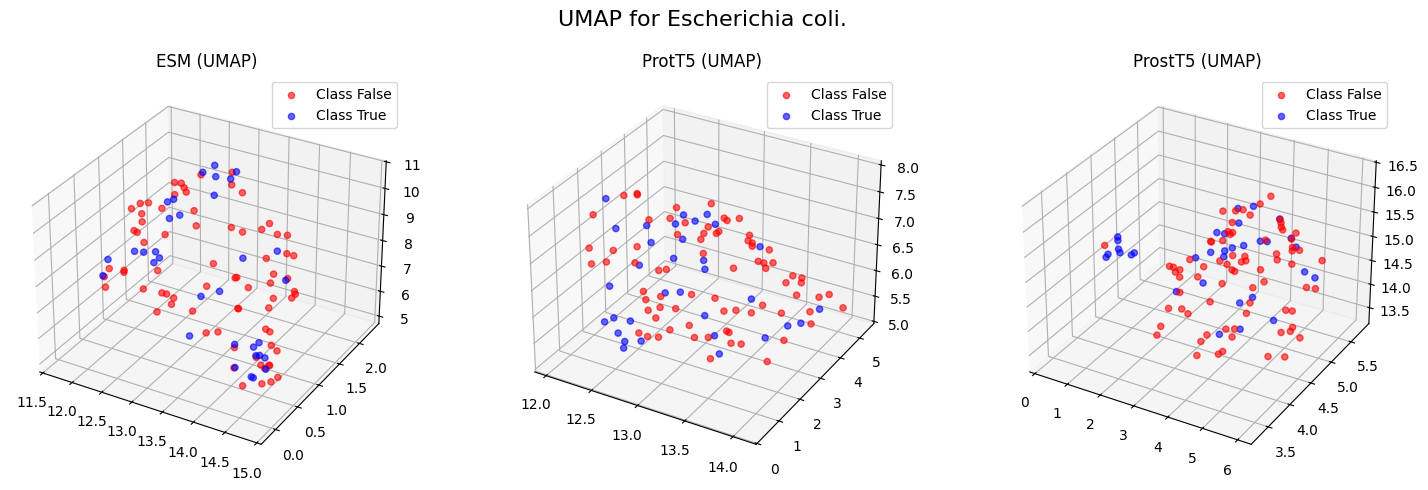

Plotting for organism: Saccharomyces cerevisiae.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

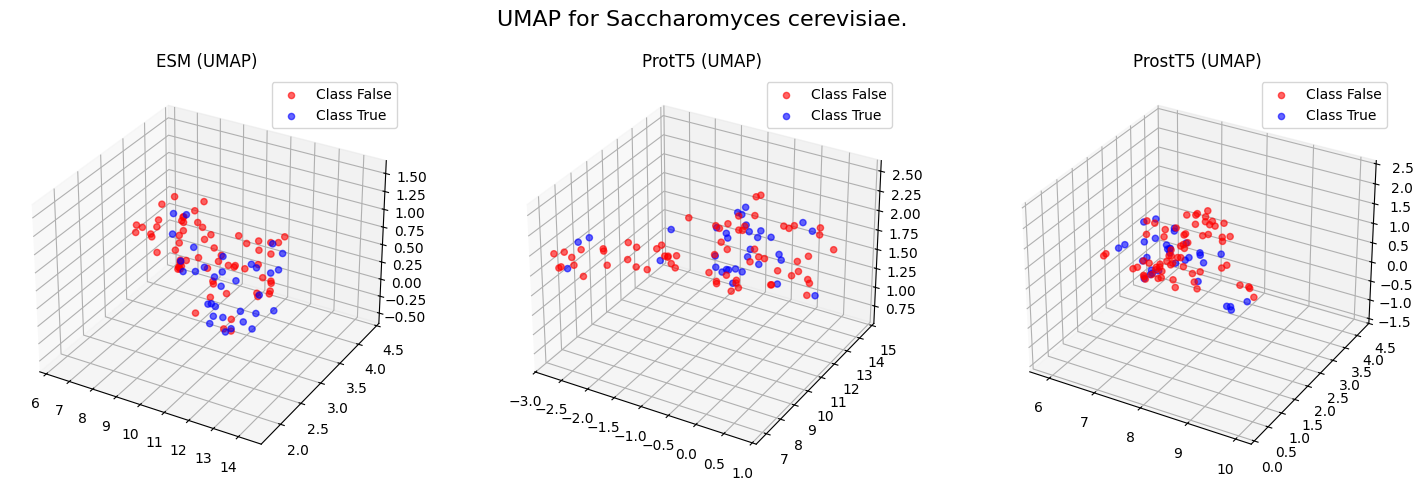

Plotting for organism: Arabidopsis thaliana.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

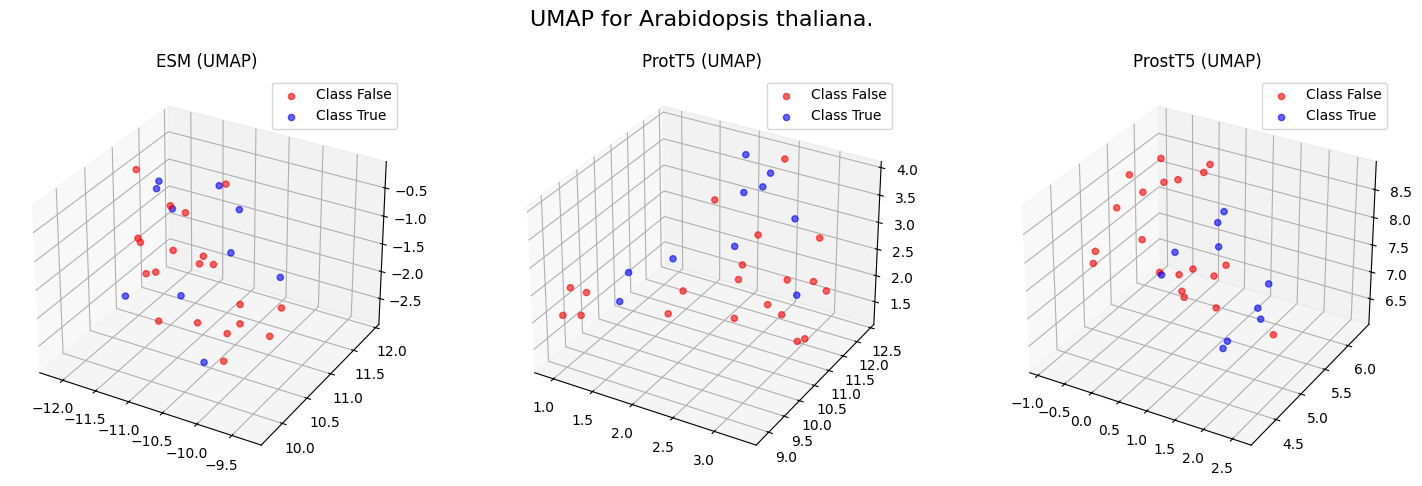

Plotting for organism: Rattus norvegicus.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

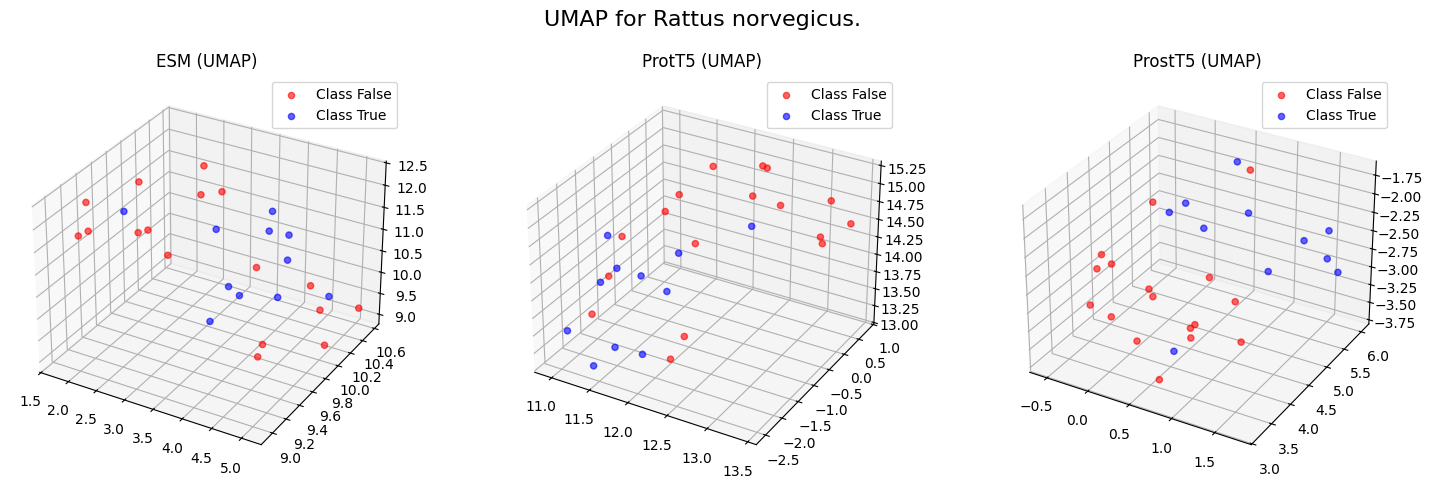

Plotting for organism: Drosophila melanogaster.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

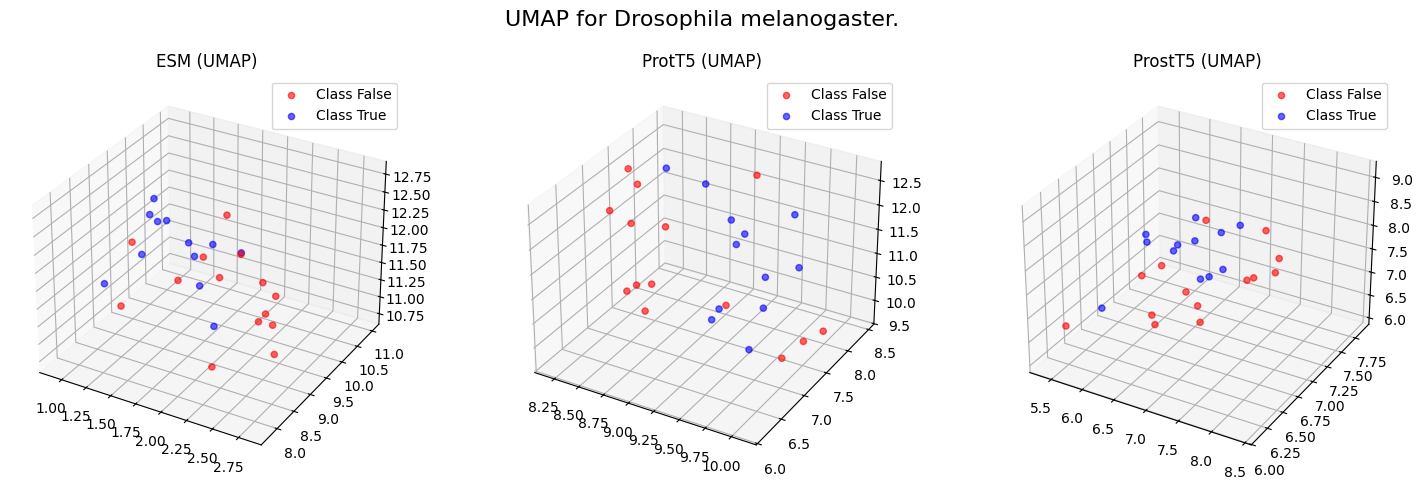

In [26]:
# Run the plots3D function for PCA for each organism
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D("UMAP", dfs_dict, label_col="class", title=f"UMAP for {organism}")

Plotting for organism: Homo sapiens.


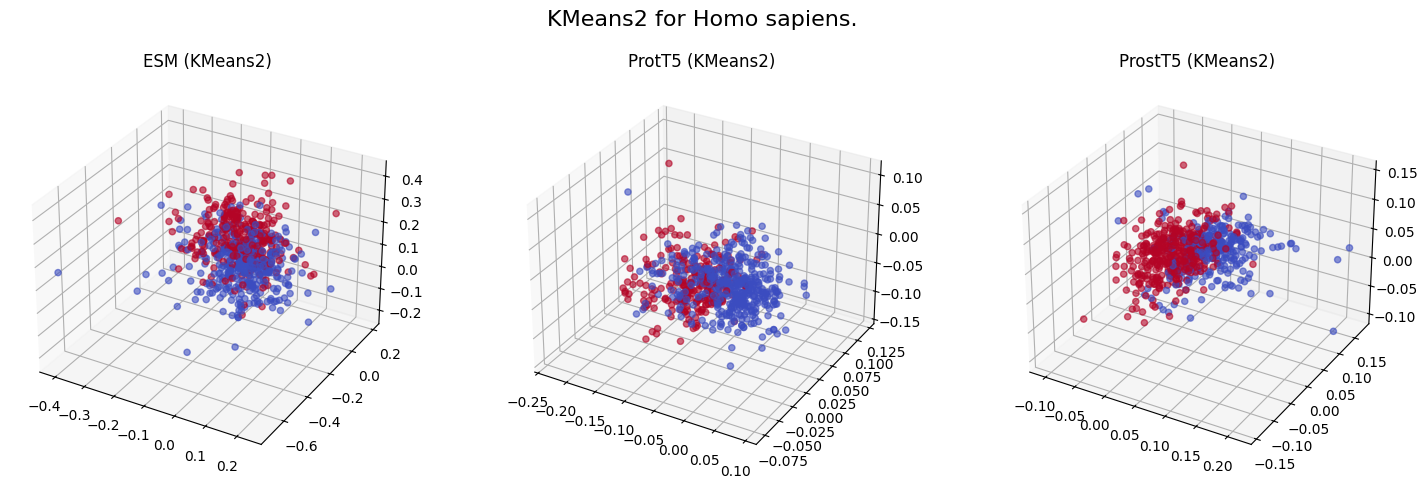

Plotting for organism: Mus musculus.


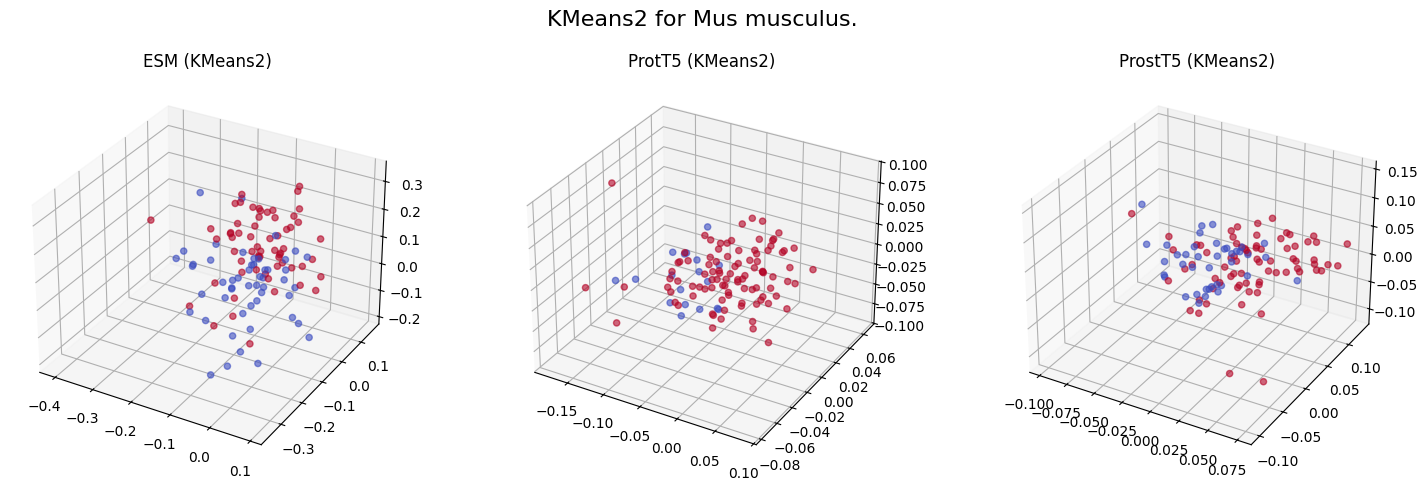

Plotting for organism: Escherichia coli.


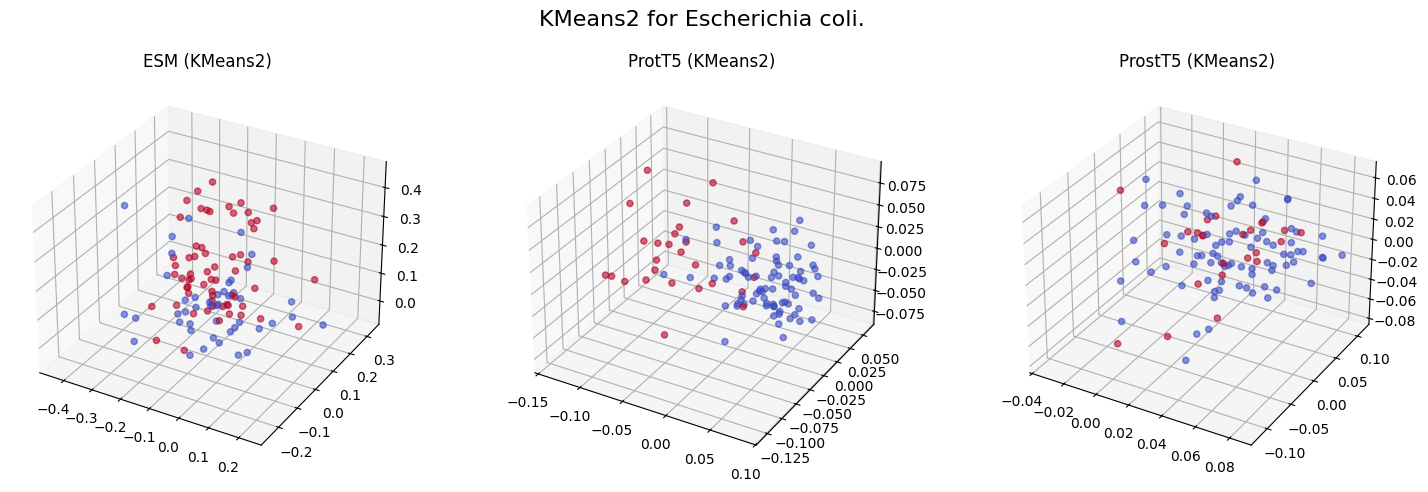

Plotting for organism: Saccharomyces cerevisiae.


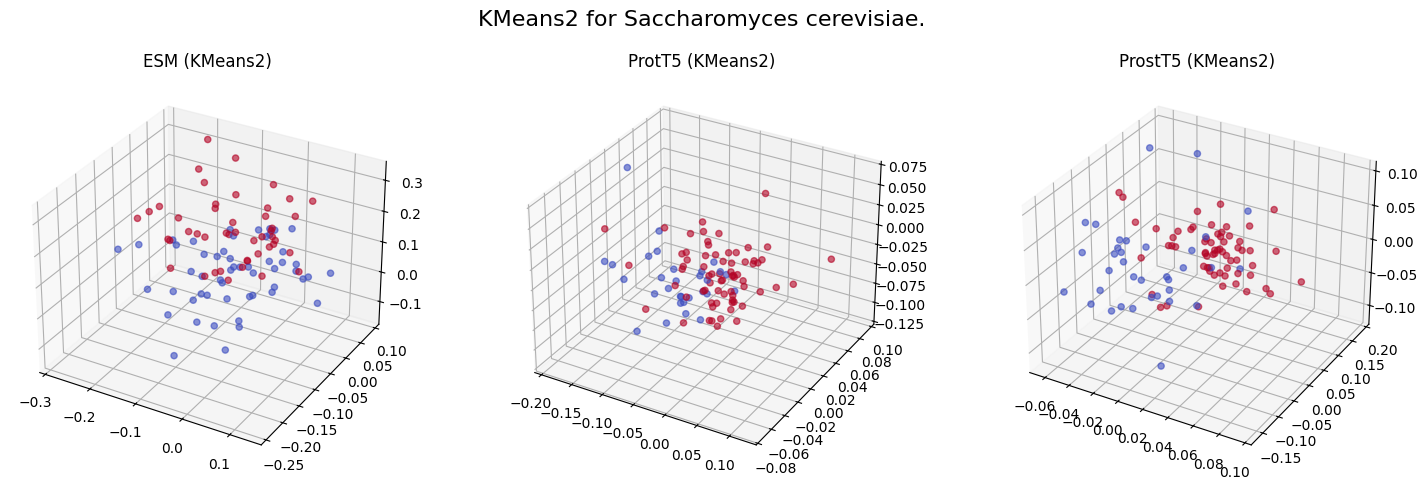

Plotting for organism: Arabidopsis thaliana.


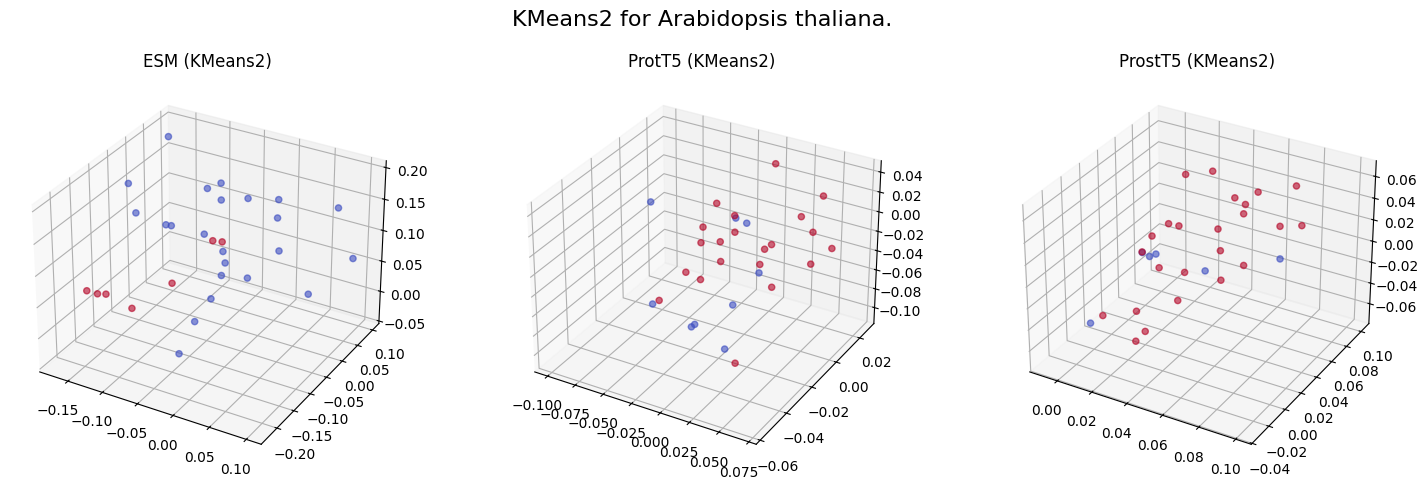

Plotting for organism: Rattus norvegicus.


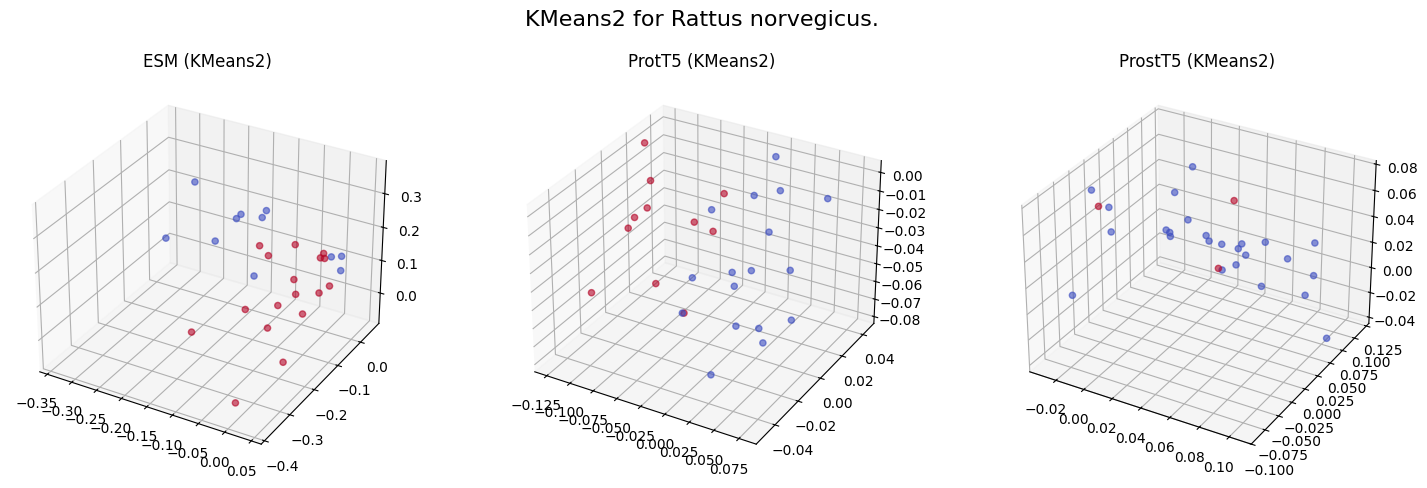

Plotting for organism: Drosophila melanogaster.


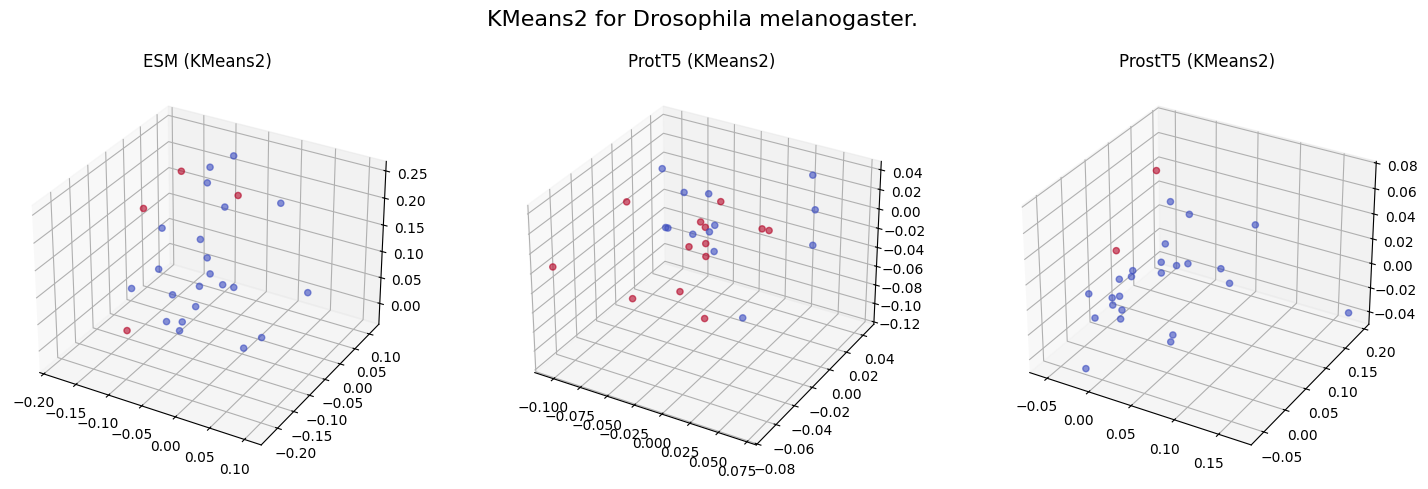

In [28]:
# Run the plots3D function for PCA for each organism
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D("KMeans2", dfs_dict, label_col="class", title=f"KMeans2 for {organism}")

In [58]:
# Create a dictionary of DataFrames for each organism
all_dfs_by_organisms = {}
for name, df_emb in all_dfs.items():
    for organism in top_4_organisms:
        filtered_df = df_emb[df_emb["organism_cleaned"] == organism]
        if organism not in all_dfs_by_organisms:
            all_dfs_by_organisms[organism] = {}
        all_dfs_by_organisms[organism][name] = filtered_df

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
import matplotlib.cm as cm  # For colormap
from matplotlib.lines import Line2D  # For custom legend

def _reduce_embeddings_3d(method, embeddings, n_components=3):
    """Helper function to reduce embeddings to 3D."""
    if method == "PCA":
        reducer = PCA(n_components=n_components)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == "KMeans2":
        reducer = KMeans(n_clusters=2, random_state=42)
        return reducer.fit_predict(embeddings)  # Return cluster labels for KMeans
    else:
        raise ValueError("Unsupported method. Use 'PCA', 'UMAP', or 'KMeans2'.")
    
    return reducer.fit_transform(embeddings)

def _get_fade_colors(values, labels, colormap_true="Blues", colormap_false="Reds"):
    """
    Generate colors with a fade effect based on the MBL values and class labels.

    Parameters:
        values (array-like): Array of MBL values to map to colors.
        labels (array-like): Array of class labels (True/False).
        colormap_true (str): Colormap for True class.
        colormap_false (str): Colormap for False class.

    Returns:
        colors (array): Array of RGBA colors.
    """
    norm = plt.Normalize(vmin=np.min(values), vmax=np.max(values))  # Normalize MBL values
    cmap_true = cm.get_cmap(colormap_true)
    cmap_false = cm.get_cmap(colormap_false)

    colors = [
        cmap_true(norm(value)) if label else cmap_false(norm(value))
        for value, label in zip(values, labels)
    ]
    return colors

def _plot_3d_with_fade(ax, reduced, mbl_values, labels, title, colormap_true="Blues", colormap_false="Reds"):
    """Helper function to plot 3D scatter with fade effect based on MBL values."""
    colors = _get_fade_colors(mbl_values, labels, colormap_true, colormap_false)
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], c=colors, alpha=0.8)
    ax.set_title(title)

    # Add legend for color intensity
    legend_elements = [
        Line2D([0], [0], color=cm.get_cmap(colormap_true)(0.5), lw=4, label="True (MBL Intensity)"),
        Line2D([0], [0], color=cm.get_cmap(colormap_false)(0.5), lw=4, label="False (MBL Intensity)")
    ]
    ax.legend(handles=legend_elements, loc="upper right")

def plots3D_with_fade(method, dfs_dict, mbl_col="c_max_mbl", label_col="class", figsize=(15, 5), title=None):
    """
    Plot PCA, UMAP, or KMeans2 for sequence embeddings in 3D with fade effect based on MBL values.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        dfs_dict (dict): Dictionary of DataFrames {name: DataFrame}.
        mbl_col (str): Column name for MBL values (default: "c_max_mbl").
        label_col (str): Column name for class labels (default: "class").
        figsize (tuple): Figure size (default: (15, 5)).
        title (str): Title for the entire plot.
    """
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontsize=16)

    for i, (name, df) in enumerate(dfs_dict.items(), start=1):
        embeddings = np.vstack(df["embedding"].to_numpy())
        mbl_values = df[mbl_col].values  # Get MBL values
        labels = df[label_col].values  # Get class labels

        ax = fig.add_subplot(1, len(dfs_dict), i, projection="3d")

        if method == "KMeans2":
            clusters = _reduce_embeddings_3d(method, embeddings)
            _plot_kmeans_3d(ax, embeddings, clusters, f"{name} ({method})")
        else:
            reduced = _reduce_embeddings_3d(method, embeddings)
            _plot_3d_with_fade(ax, reduced, mbl_values, labels, f"{name} ({method})")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [59]:
# Ensure MBL values are included in dfs_dict entries
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Processing organism: {organism}")
    
    for model_name, df in dfs_dict.items():
        # Merge MBL values from df_top_7_filtered into the current DataFrame
        dfs_dict[model_name] = df.merge(
            df_top_7_filtered[["accession_code", "c_max_mbl", "f_max_mbl", "p_max_mbl"]],
            how="left",
            on="accession_code"
        )
        print(f"Updated {model_name} DataFrame for {organism} with MBL values.")

Processing organism: Homo sapiens.
Updated ESM DataFrame for Homo sapiens. with MBL values.
Updated ProtT5 DataFrame for Homo sapiens. with MBL values.
Updated ProstT5 DataFrame for Homo sapiens. with MBL values.
Processing organism: Mus musculus.
Updated ESM DataFrame for Mus musculus. with MBL values.
Updated ProtT5 DataFrame for Mus musculus. with MBL values.
Updated ProstT5 DataFrame for Mus musculus. with MBL values.
Processing organism: Escherichia coli.
Updated ESM DataFrame for Escherichia coli. with MBL values.
Updated ProtT5 DataFrame for Escherichia coli. with MBL values.
Updated ProstT5 DataFrame for Escherichia coli. with MBL values.
Processing organism: Saccharomyces cerevisiae.
Updated ESM DataFrame for Saccharomyces cerevisiae. with MBL values.
Updated ProtT5 DataFrame for Saccharomyces cerevisiae. with MBL values.
Updated ProstT5 DataFrame for Saccharomyces cerevisiae. with MBL values.


Plotting for organism: Homo sapiens.


/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_false = cm.get_cmap(colormap_false)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
 

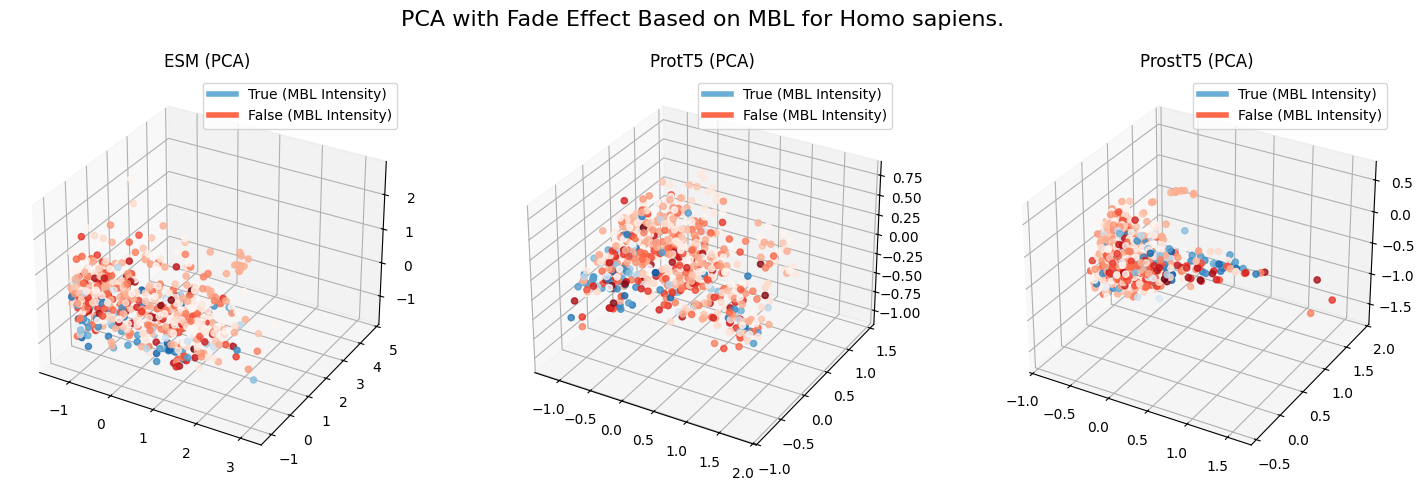

Plotting for organism: Mus musculus.


/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_false = cm.get_cmap(colormap_false)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
 

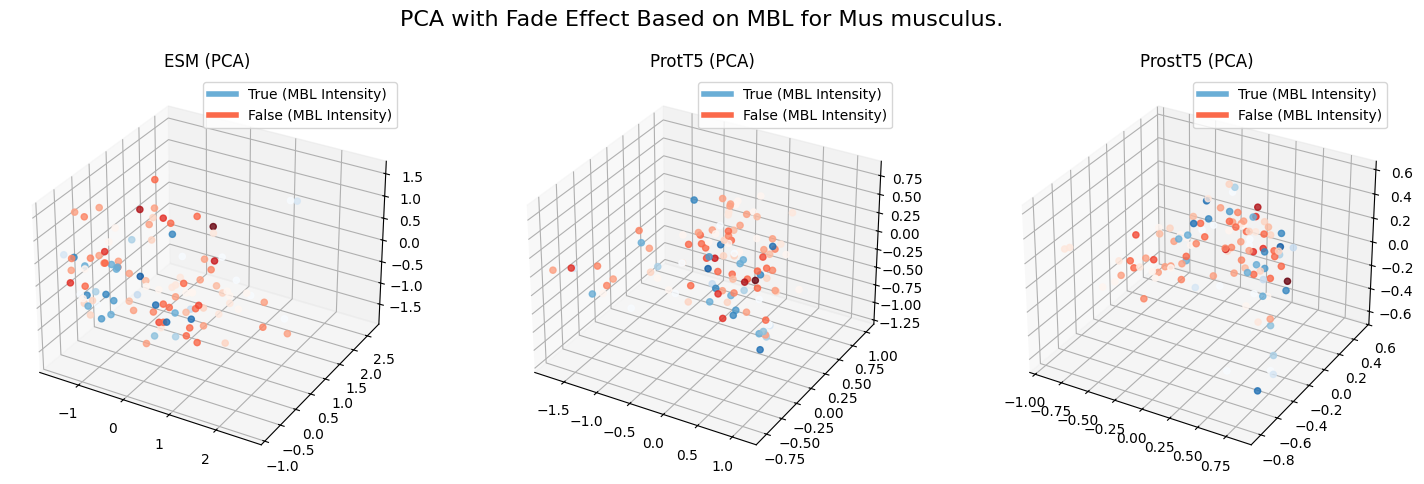

Plotting for organism: Escherichia coli.


/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_false = cm.get_cmap(colormap_false)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
 

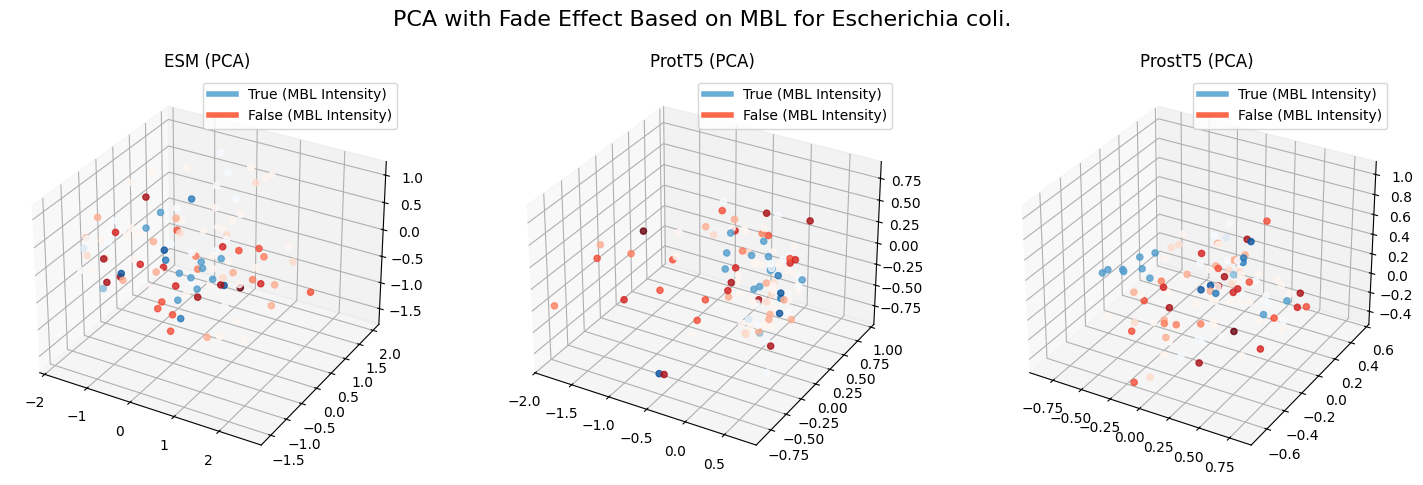

Plotting for organism: Saccharomyces cerevisiae.


/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_false = cm.get_cmap(colormap_false)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
 

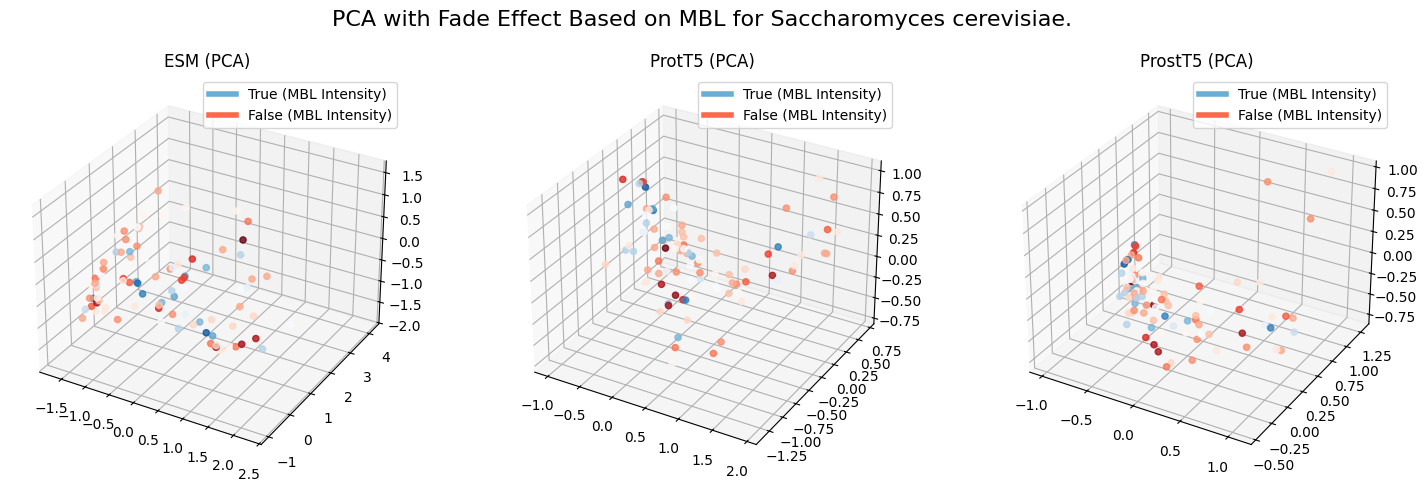

In [60]:
# Plotting with fade effect based on MBL values
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D_with_fade(
        "PCA",
        dfs_dict=dfs_dict,
        mbl_col="c_max_mbl",  # Use the MBL column for the fade effect
        label_col="class",
        title=f"PCA with Fade Effect Based on MBL for {organism}"
    )

Plotting for organism: Homo sapiens.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib

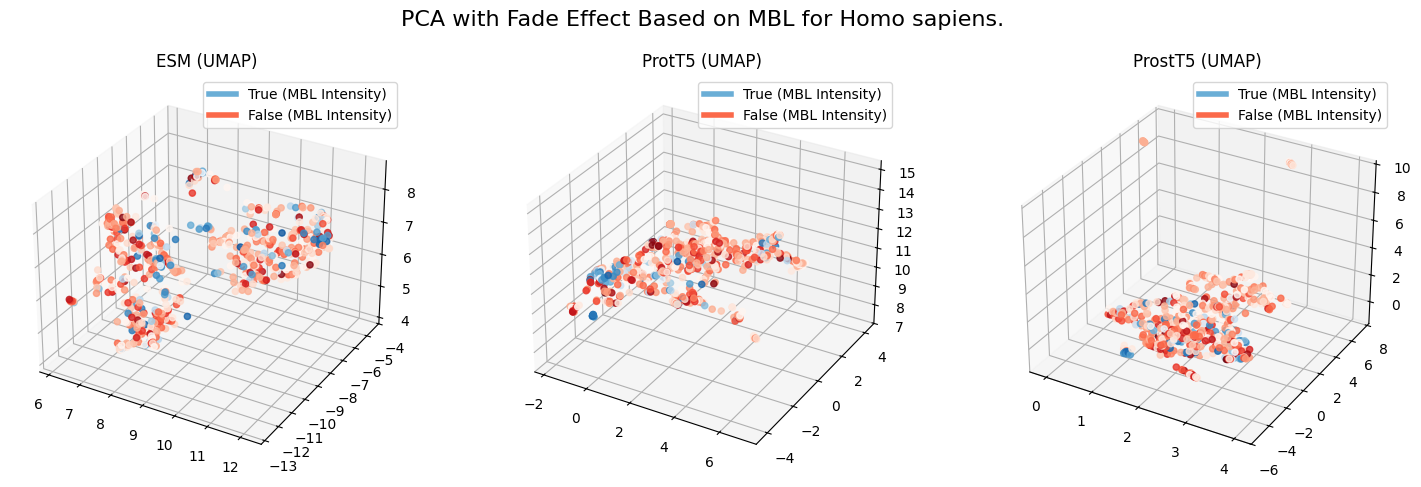

Plotting for organism: Mus musculus.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib

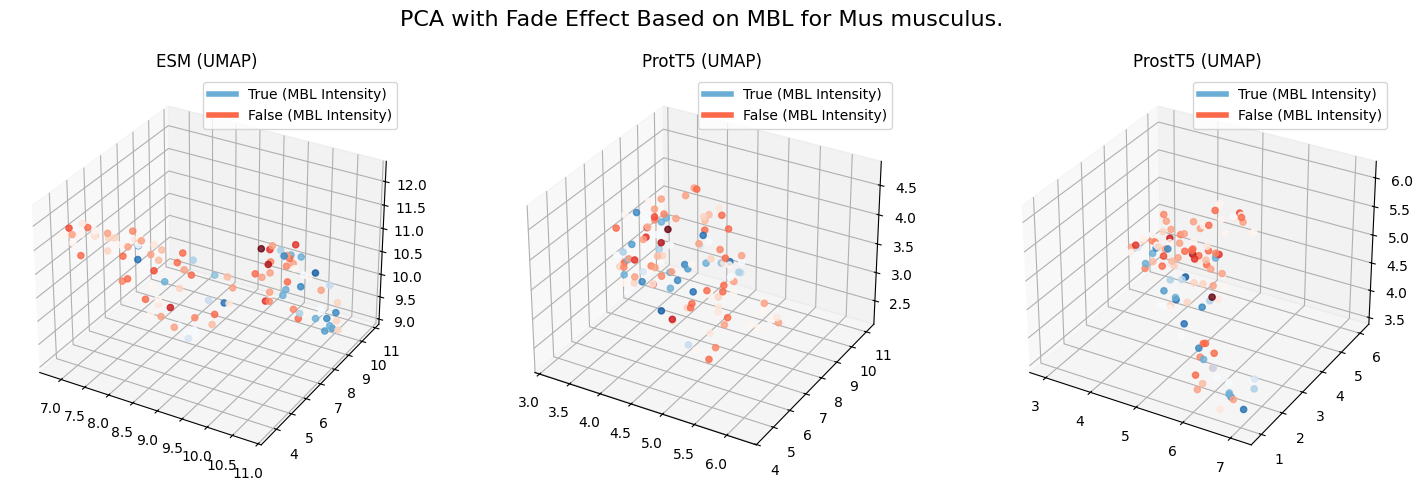

Plotting for organism: Escherichia coli.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib

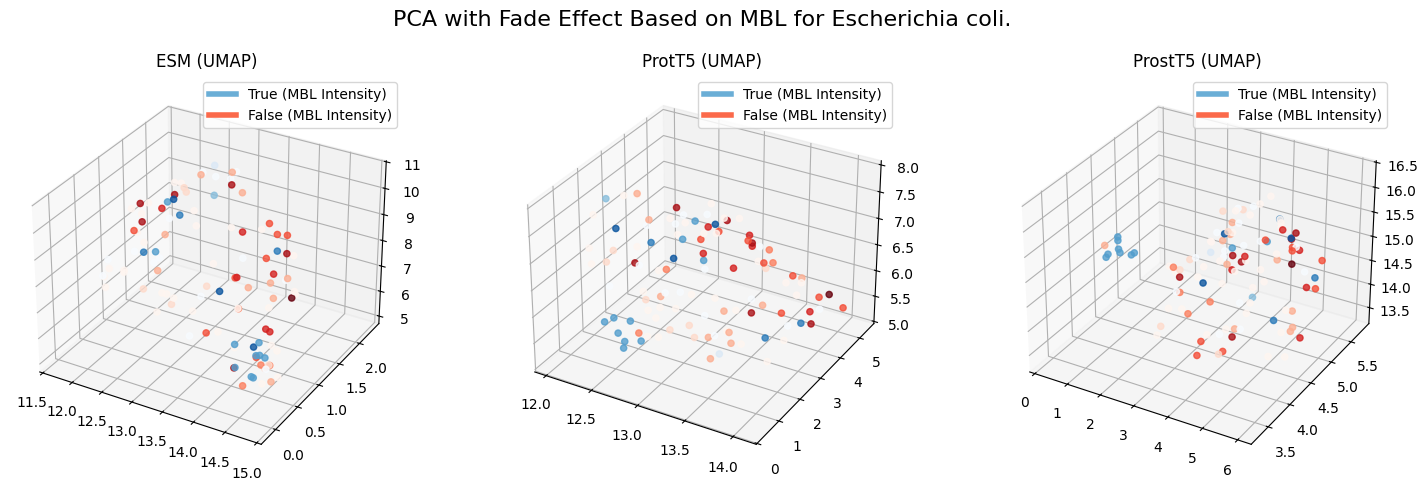

Plotting for organism: Saccharomyces cerevisiae.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_true = cm.get_cmap(colormap_true)
/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_41173/4233077960.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib

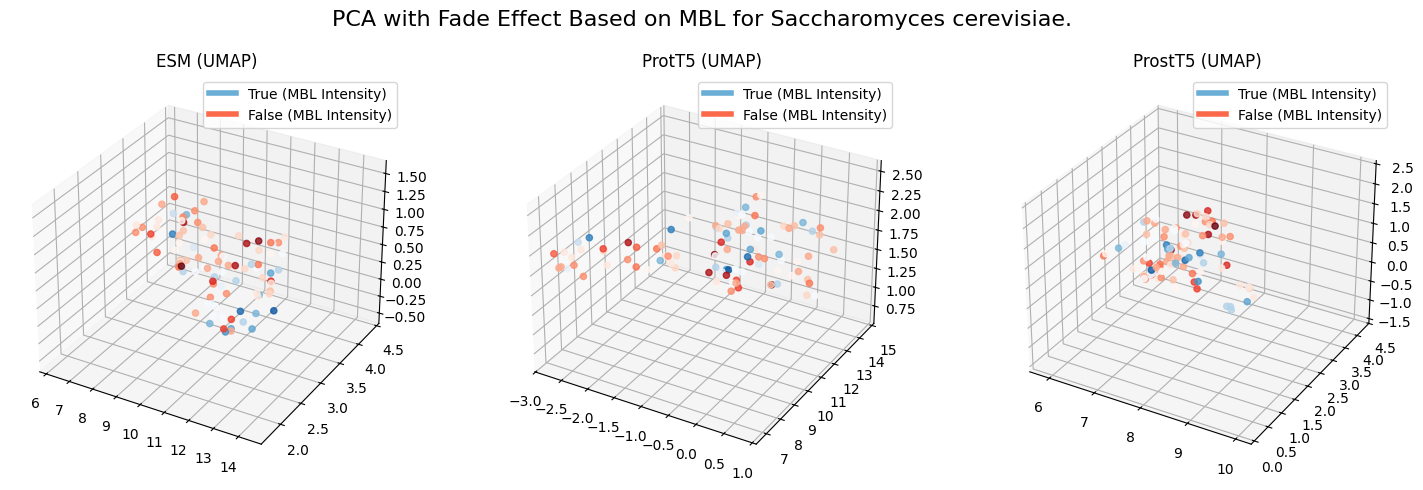

In [61]:
# Plotting with fade effect based on MBL values
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D_with_fade(
        "UMAP",
        dfs_dict=dfs_dict,
        mbl_col="c_max_mbl",  # Use the MBL column for the fade effect
        label_col="class",
        title=f"PCA with Fade Effect Based on MBL for {organism}"
    )